# Day 2: HAM10000 skin lesion classifier
Runtime > Change runtime type > **T4 GPU**, then Run all (about 25-35 min).

In [2]:
import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

Tesla T4


In [3]:
!git clone -q https://github.com/aryan9-6-5/MedTech-Suite.git
%cd MedTech-Suite/day-2-ham10000-skin-lesion-classifier
!mkdir -p data results

/content/MedTech-Suite/day-2-ham10000-skin-lesion-classifier


In [4]:
# HAM10000 from Harvard Dataverse (CC BY-NC 4.0): ~2.8 GB of images + metadata
!cd data && curl -sL -o HAM10000_metadata.tab https://dataverse.harvard.edu/api/access/datafile/4338392
!cd data && curl -sL -o HAM10000_images_part_1.zip https://dataverse.harvard.edu/api/access/datafile/3172585 &
!cd data && curl -sL -o HAM10000_images_part_2.zip https://dataverse.harvard.edu/api/access/datafile/3172584 &
!wait
!ls -la data

total 2705996
drwxr-xr-x 2 root root       4096 Oct  8 14:51 .
drwxr-xr-x 6 root root       4096 Oct  8 14:51 ..
-rw-r--r-- 1 root root 1366522108 Oct  8 14:51 HAM10000_images_part_1.zip
-rw-r--r-- 1 root root 1403566547 Oct  8 14:52 HAM10000_images_part_2.zip
-rw-r--r-- 1 root root     830428 Oct  8 14:51 HAM10000_metadata.tab


In [5]:
# sanity check the downloads before training
import zipfile, glob
for z in sorted(glob.glob('data/HAM10000_images_part_*.zip')):
    print(z, len(zipfile.ZipFile(z).namelist()), 'files')   # expect 5000 + 5015

data/HAM10000_images_part_1.zip 5000 files
data/HAM10000_images_part_2.zip 5015 files


In [6]:
%cd src
!python train.py

/content/MedTech-Suite/day-2-ham10000-skin-lesion-classifier/src
{'train': 6984, 'val': 1524, 'test': 1507}
split=grouped: lesions shared between train and test = 0
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100% 109M/109M [00:01<00:00, 73.0MB/s] 
epoch 01 val macro AUROC 0.9252  bal.acc 0.509
epoch 02 val macro AUROC 0.9174  bal.acc 0.617
epoch 03 val macro AUROC 0.9612  bal.acc 0.727
epoch 04 val macro AUROC 0.9551  bal.acc 0.679
epoch 05 val macro AUROC 0.9695  bal.acc 0.745
epoch 06 val macro AUROC 0.9509  bal.acc 0.735
epoch 07 val macro AUROC 0.9542  bal.acc 0.749
epoch 08 val macro AUROC 0.9551  bal.acc 0.737
epoch 09 val macro AUROC 0.9518  bal.acc 0.790
epoch 10 val macro AUROC 0.9530  bal.acc 0.792
epoch 11 val macro AUROC 0.9488  bal.acc 0.779
epoch 12 val macro AUROC 0.9503  bal.acc 0.768
epoch 13 val macro AUROC 0.9505  bal.acc 0.791
epoch 14 val macro AUROC 0.9501  bal.acc 

In [7]:
!python evaluate.py

done [('correct', np.int64(324)), ('missed', np.int64(242))]


/content/MedTech-Suite/day-2-ham10000-skin-lesion-classifier
{
  "split": "grouped",
  "lesions_shared_train_test": 0,
  "best_val_macro_auc": 0.9694802651805191,
  "best_epoch": 5,
  "test_macro_auc": 0.9277178968929655,
  "test_macro_auc_ci95": [
    0.9005736157660205,
    0.9520794463269989
  ],
  "test_balanced_acc": 0.677829119658733,
  "test_accuracy": 0.783012607830126,
  "test_auc_per_class": {
    "akiec": 0.9631203263086335,
    "bcc": 0.9536760955706381,
    "bkl": 0.9386024451077402,
    "df": 0.8636669727578818,
    "mel": 0.8987400745422137,
    "nv": 0.9390755409171914,
    "vasc": 0.93714382304646
  },
  "melanoma_recall_at_argmax": 0.7112299465240641,
  "test_class_counts": {
    "akiec": 36,
    "bcc": 71,
    "bkl": 185,
    "df": 22,
    "mel": 187,
    "nv": 978,
    "vasc": 28
  },
  "n_train": 6984,
  "n_val": 1524,
  "n_test": 1507
}


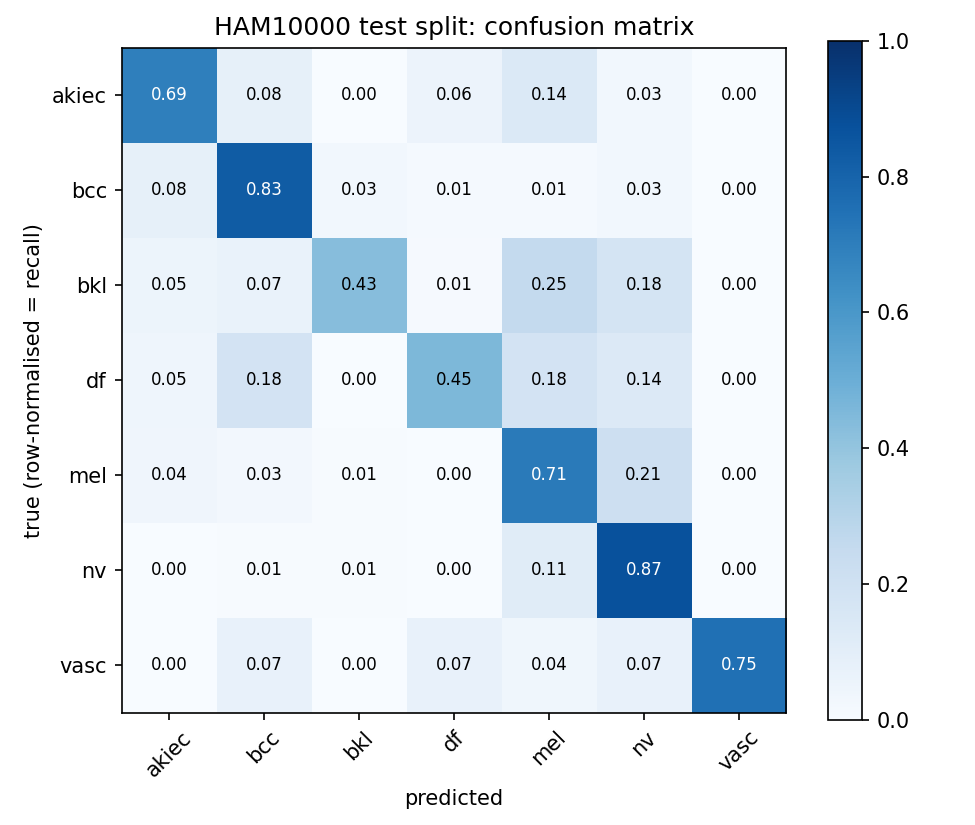

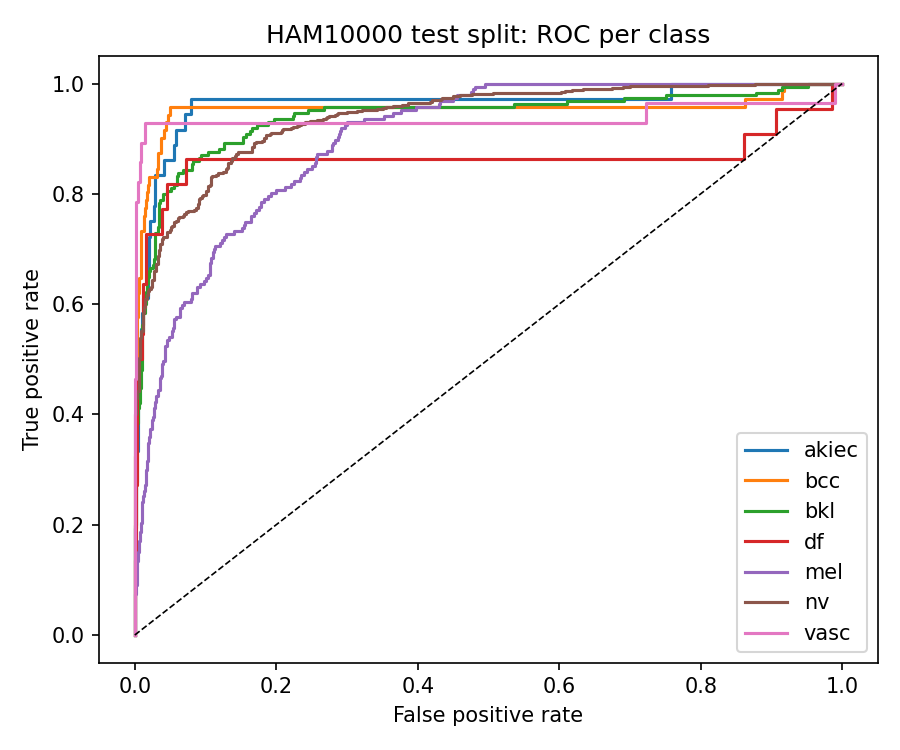

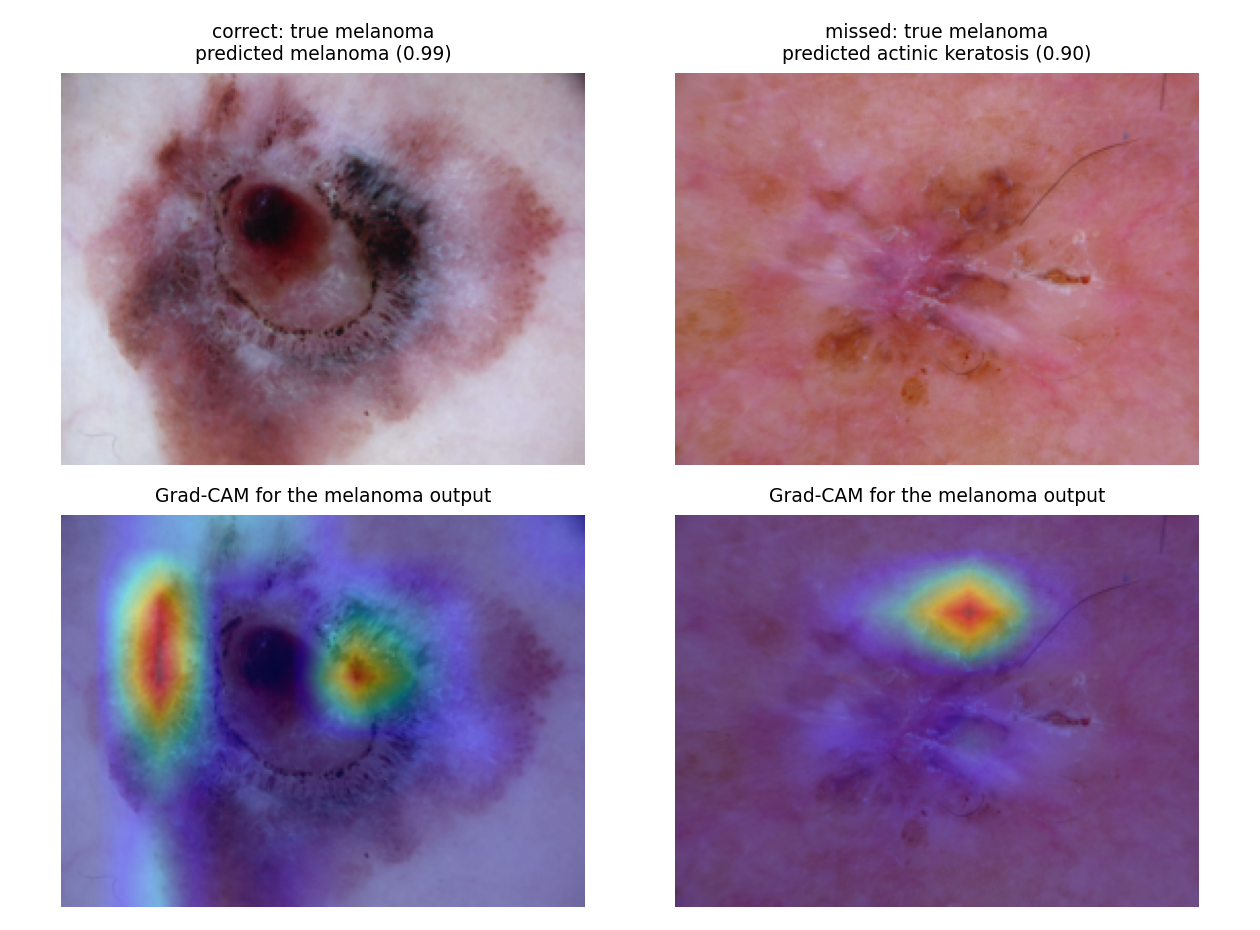

In [8]:
%cd ..
import json
from IPython.display import Image, display
m=json.load(open('results/metrics.json')); m.pop('history'); print(json.dumps(m, indent=2))
for f in ('confusion','roc','gradcam_mel'): display(Image(f'results/{f}.png'))

### Optional: leakage comparison
Same model, but a *random* image-level split that ignores `lesion_id`. Shows how much a leaky split flatters the score (about 10 more minutes).


In [9]:
%cd src
!SPLIT=random python train.py
%cd ..
import json
a=json.load(open('results/metrics.json')); b=json.load(open('results/metrics_random.json'))
print('grouped  macro AUROC', round(a['test_macro_auc'],4), ' shared lesions', a['lesions_shared_train_test'])
print('random   macro AUROC', round(b['test_macro_auc'],4), ' shared lesions', b['lesions_shared_train_test'])

/content/MedTech-Suite/day-2-ham10000-skin-lesion-classifier/src
{'train': 7014, 'val': 1501, 'test': 1500}
split=random: lesions shared between train and test = 496
epoch 01 val macro AUROC 0.9517  bal.acc 0.617
epoch 02 val macro AUROC 0.9559  bal.acc 0.746
epoch 03 val macro AUROC 0.9706  bal.acc 0.762
epoch 04 val macro AUROC 0.9705  bal.acc 0.785
epoch 05 val macro AUROC 0.9676  bal.acc 0.712
epoch 06 val macro AUROC 0.9757  bal.acc 0.864
epoch 07 val macro AUROC 0.9697  bal.acc 0.846
epoch 08 val macro AUROC 0.9700  bal.acc 0.873
epoch 09 val macro AUROC 0.9709  bal.acc 0.843
epoch 10 val macro AUROC 0.9757  bal.acc 0.866
epoch 11 val macro AUROC 0.9728  bal.acc 0.838
epoch 12 val macro AUROC 0.9732  bal.acc 0.858
epoch 13 val macro AUROC 0.9718  bal.acc 0.840
epoch 14 val macro AUROC 0.9724  bal.acc 0.839
epoch 15 val macro AUROC 0.9723  bal.acc 0.843
{
  "split": "random",
  "lesions_shared_train_test": 496,
  "best_val_macro_auc": 0.9757240482957327,
  "best_epoch": 10,
  "tes

In [10]:
import os
import shutil
import time
from pathlib import Path

# 1. Ensure we are in repository root
if Path.cwd().name == "src":
    os.chdir("..")

results_dir = Path("results")
zip_path = Path("results.zip")

# 2. Create the zip archive
if zip_path.exists():
    zip_path.unlink()

print("Creating results.zip...")
shutil.make_archive("results", "zip", "results")
zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"Archive ready: results.zip ({zip_size_mb:.2f} MB)")

# 3. Trigger download to your local PC
from google.colab import files
print("\nInitiating download to your computer...")
files.download(str(zip_path))

# 4. Give the browser time to finish downloading before deleting
wait_seconds = 20  # adjust if your internet speed is slower
print(f"Waiting {wait_seconds}s for browser download stream to complete...")
time.sleep(wait_seconds)

# 5. Clean up from Google Drive (if you saved it there)
drive_dest = Path("/content/drive/MyDrive/MedTech-Suite/day-2-ham10000/results")
drive_zip = Path("/content/drive/MyDrive/MedTech-Suite/day-2-ham10000/results.zip")

if drive_dest.exists():
    shutil.rmtree(drive_dest)
    print(f"Removed folder from Google Drive: {drive_dest}")

if drive_zip.exists():
    drive_zip.unlink()
    print(f"Removed zip from Google Drive: {drive_zip}")

# 6. Clean up from Colab local disk
if zip_path.exists():
    zip_path.unlink()
    print("Deleted local results.zip")


print("\n Done! Results downloaded and storage cleaned up.")


Creating results.zip...
Archive ready: results.zip (198.10 MB)

Initiating download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Waiting 20s for browser download stream to complete...
Deleted local results.zip

 Done! Results downloaded and storage cleaned up.
